# QRT Challenge Data ENS #167
### Predicting the Sign of Next-Day Returns for Asset Allocation Strategies

**Thea Alfon, Antoine Maruenda, Sami Strack**  
ML for Finance - Master's Project  

---

This notebook documents our full approach to the QRT Challenge Data ENS #167, hosted on Challenge Data ENS. The competition asks participants to predict whether the next-day return of an asset allocation strategy will be positive or negative - a binary classification problem.

We chose this challenge as our Free-Ride track project because it sits at the intersection of several difficulties that make financial ML genuinely hard: a very weak signal, a deliberately adversarial test set structure, and almost no guidance on what features to build. The scientific process we went through - including dead ends - is what we think makes this project worth presenting.

## Table of Contents

1. [Problem Statement](#1)
2. [Data Exploration](#2)
3. [Feature Engineering](#3)
4. [Models](#4)
5. [The Core Challenge: Distribution Shift](#5)
6. [Results and Iterations](#6)
7. [Conclusion](#7)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# load data
X_train = pd.read_csv('X_train.csv', index_col='ROW_ID')
X_test  = pd.read_csv('X_test.csv',  index_col='ROW_ID')
y_train = pd.read_csv('y_train.csv', index_col='ROW_ID')

RET_COLS = [f'RET_{i}' for i in range(1, 21)]
SV_COLS  = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]
eps = 1e-8

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')

X_train : (527073, 44)
X_test  : (31870, 44)
y_train : (527073, 1)


<a id='1'></a>
## 1. Problem Statement

### 1.1 The Challenge

QRT (Qube Research & Technologies) is a systematic hedge fund. This challenge gives participants access to a dataset of historical returns and volume data for ~278 asset allocation strategies, and asks them to predict whether the return of each strategy on the next day will be positive or negative.

Formally: given features at time $t$, predict $\text{sign}(r_{t+1}) \in \{0, 1\}$.

The evaluation metric is **accuracy** against a 50/50 balanced test set. The public benchmark (a simple LightGBM on raw features) sits at **0.5079**. Our best submission reached **0.5116**.

### 1.2 Why this is hard

Several things make this problem genuinely difficult, beyond the typical ML classification setup:

- **The signal is extremely weak.** A model that gets 52-53% accuracy is doing very well. The theoretical maximum, if it exists at all, is probably around 54-55% given the inherent unpredictability of short-term returns.

- **The test set is deliberately different from the training set.** QRT designed the test set to reward robust generalization, not overfitting to the training distribution. We spent a significant part of this project understanding exactly how and why, and building tools to detect which features are robust to this shift.

- **No feature guidance is given.** The dataset provides raw return and volume series. All feature engineering decisions are left to the participant.

### 1.3 Our approach in a nutshell

We went through three main phases:

1. Build a strong GBDT baseline with cross-sectional features and allocation profiles
2. Attempt deep learning (Transformer, supervised Autoencoder) - both failed to generalize
3. Build a principled stability analysis framework to understand the CV/public gap and clean up the feature set

The third phase is what we are most proud of scientifically.

<a id='2'></a>
## 2. Data Exploration

### 2.1 Dataset Structure

In [26]:
# basic dataset stats
n_allocs_train = X_train['ALLOCATION'].nunique()
n_ts_train     = X_train['TS'].nunique()
n_allocs_test  = X_test['ALLOCATION'].nunique()
n_ts_test      = X_test['TS'].nunique()

print('=== Dataset Overview ===')
print(f'Training observations : {len(X_train):,}')
print(f'Test observations     : {len(X_test):,}')
print(f'Unique allocations    : {n_allocs_train} (train) / {n_allocs_test} (test)')
print(f'Unique timestamps     : {n_ts_train} (train) / {n_ts_test} (test)')
print(f'\nFeatures available    : {X_train.shape[1]}')
print(f'  - Return series     : RET_1 to RET_20 (t to t-19)')
print(f'  - Volume series     : SIGNED_VOLUME_1 to SIGNED_VOLUME_20')
print(f'  - Other             : MEDIAN_DAILY_TURNOVER, GROUP (1-4), ALLOCATION, TS')
print(f'\nTarget distribution   : {(y_train["target"] > 0).mean():.4f} positive days')

=== Dataset Overview ===
Training observations : 527,073
Test observations     : 31,870
Unique allocations    : 278 (train) / 278 (test)
Unique timestamps     : 2522 (train) / 120 (test)

Features available    : 44
  - Return series     : RET_1 to RET_20 (t to t-19)
  - Volume series     : SIGNED_VOLUME_1 to SIGNED_VOLUME_20
  - Other             : MEDIAN_DAILY_TURNOVER, GROUP (1-4), ALLOCATION, TS

Target distribution   : 0.5072 positive days


The dataset has a panel structure: each row corresponds to one (allocation, timestamp) pair. RET_1 is the most recent return (yesterday), RET_2 the day before that, and so on up to RET_20. The target is the sign of tomorrow's return, which is not in the dataset.

The four GROUPs correspond to different strategy families with distinct market exposure profiles, as we show below.

In [27]:
# group structure and beta estimates
market_ret = X_train.groupby('TS')['RET_1'].mean()

group_stats = []
for g in [1, 2, 3, 4]:
    sub = X_train[X_train['GROUP'] == g]
    n_allocs = sub['ALLOCATION'].nunique()
    n_obs    = len(sub)

    # estimate beta vs market
    alloc_ret = sub.groupby('TS')['RET_1'].mean()
    common_ts = alloc_ret.index.intersection(market_ret.index)
    cov_mat   = np.cov(alloc_ret[common_ts].values, market_ret[common_ts].values)
    beta      = cov_mat[0, 1] / (cov_mat[1, 1] + eps)

    # predictability
    y_sub     = (y_train.loc[sub.index, 'target'] > 0).values
    mom_acc   = ((sub['RET_1'].values > 0) == y_sub).mean()

    group_stats.append({
        'GROUP': g,
        'n_allocations': n_allocs,
        'n_observations': n_obs,
        'beta_vs_market': round(beta, 3),
        'momentum_accuracy': round(mom_acc, 4),
        'hit_rate': round(y_sub.mean(), 4),
    })

group_df = pd.DataFrame(group_stats).set_index('GROUP')
print('=== Group Profiles ===')
print(group_df.to_string())

=== Group Profiles ===
       n_allocations  n_observations  beta_vs_market  momentum_accuracy  hit_rate
GROUP                                                                            
1                 70          100170           1.393             0.5231    0.5005
2                 70          134928           0.818             0.5219    0.5098
3                 70          168913           1.059             0.5146    0.5099
4                 68          123062           0.653             0.5182    0.5060


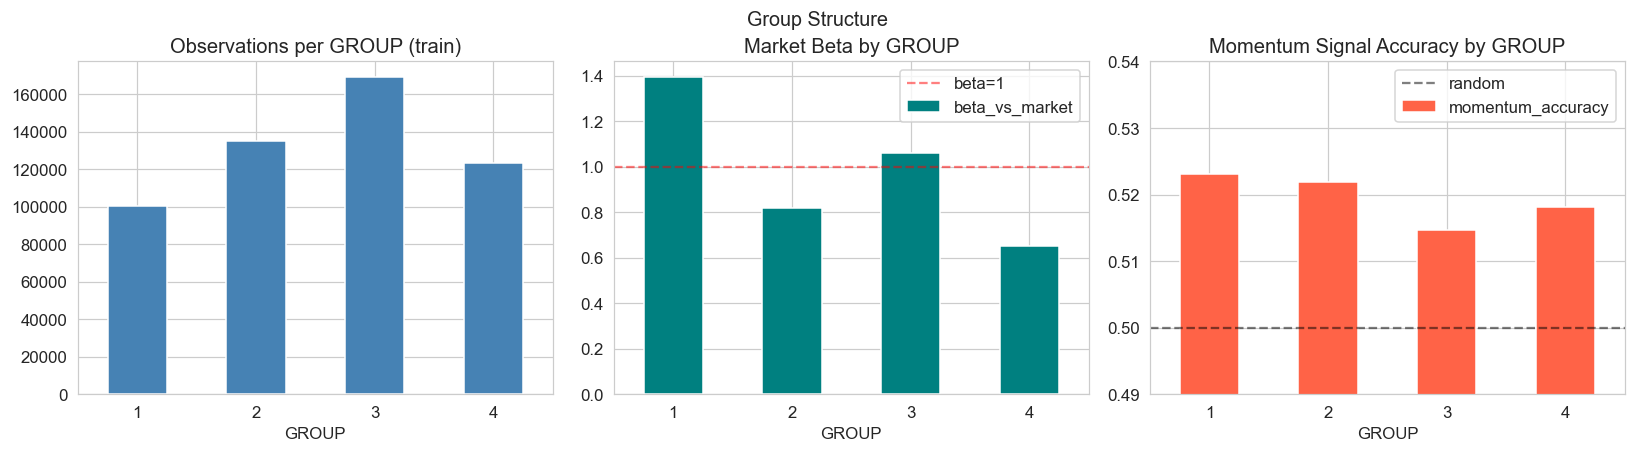

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# group sizes
group_df['n_observations'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Observations per GROUP (train)')
axes[0].set_xlabel('GROUP')
axes[0].tick_params(axis='x', rotation=0)

# beta by group
group_df['beta_vs_market'].plot(
    kind='bar', ax=axes[1], color='teal', edgecolor='white'
)
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='beta=1')
axes[1].set_title('Market Beta by GROUP')
axes[1].set_xlabel('GROUP')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

# momentum accuracy by group
group_df['momentum_accuracy'].plot(
    kind='bar', ax=axes[2], color='tomato', edgecolor='white'
)
axes[2].axhline(0.5, color='black', linestyle='--', alpha=0.5, label='random')
axes[2].set_title('Momentum Signal Accuracy by GROUP')
axes[2].set_xlabel('GROUP')
axes[2].set_ylim(0.49, 0.54)
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend()

plt.tight_layout()
plt.suptitle('Group Structure', y=1.02, fontsize=13)
plt.show()

A few things stand out here. GROUP 3 is by far the most represented in training (~168k observations vs ~100k for GROUP 1), but GROUP 1 has the strongest momentum signal (52.3% accuracy) and the highest market beta (1.39). GROUP 4 looks like a long-short or market-neutral strategy family (beta 0.65, weakest signal).

The momentum signal is positive across all groups - meaning yesterday's return direction is a modest but consistent predictor of tomorrow's. This rules out simple mean-reversion as the dominant regime.

### 2.2 The Missing Volume Problem

SIGNED_VOLUME_1 missing rate : 73.5%
SIGNED_VOLUME_2 missing rate : 0.0%
SIGNED_VOLUME_20 missing rate: 1.6%

Allocations with SV1 always available : 24 / 278
These 24 allocations likely have real-time volume data - useful as a conditioning flag


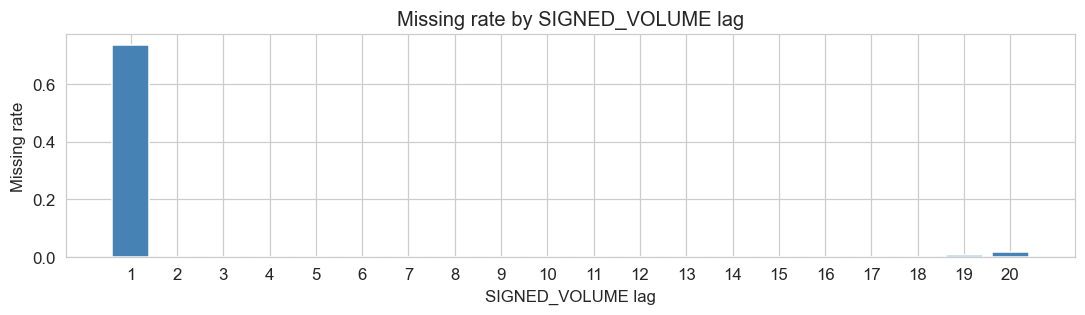

In [29]:
# SIGNED_VOLUME_1 missing rate - this is a big deal
sv1_missing = X_train['SIGNED_VOLUME_1'].isna().mean()
sv_missing  = X_train[SV_COLS].isna().mean()

print(f'SIGNED_VOLUME_1 missing rate : {sv1_missing:.1%}')
print(f'SIGNED_VOLUME_2 missing rate : {sv_missing["SIGNED_VOLUME_2"]:.1%}')
print(f'SIGNED_VOLUME_20 missing rate: {sv_missing["SIGNED_VOLUME_20"]:.1%}')

# the 24 special allocations with SV1 always available
sv1_avail = X_train.groupby('ALLOCATION')['SIGNED_VOLUME_1'].apply(
    lambda x: x.notna().mean()
)
special_allocs = sv1_avail[sv1_avail > 0.99]
print(f'\nAllocations with SV1 always available : {len(special_allocs)} / {sv1_avail.shape[0]}')
print('These 24 allocations likely have real-time volume data - useful as a conditioning flag')

fig, ax = plt.subplots(figsize=(10, 3))
sv_missing.values[::-1]
ax.bar(range(1, 21), [X_train[f'SIGNED_VOLUME_{i}'].isna().mean() for i in range(1, 21)],
       color='steelblue', edgecolor='white')
ax.set_xlabel('SIGNED_VOLUME lag')
ax.set_ylabel('Missing rate')
ax.set_title('Missing rate by SIGNED_VOLUME lag')
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.show()

SIGNED_VOLUME_1 (the most recent volume observation) is missing for 73% of the dataset. This is a major constraint: any model that relies on yesterday's volume will be working with mostly zeros after imputation. We decided to use volume features only from lag 2 onwards, which have much lower missing rates.

### 2.3 The Structural Difference Between Train and Test

This is the single most important finding from our EDA, and it shaped everything that came after.

In [30]:
# density = number of allocations present at each timestamp
train_density = X_train.groupby('TS')['ALLOCATION'].count()
test_density  = X_test.groupby('TS')['ALLOCATION'].count()

print('=== Timestamp Density ===')
print(f'Train - mean: {train_density.mean():.1f}  median: {train_density.median():.0f}  '
      f'min: {train_density.min()}  max: {train_density.max()}')
print(f'Test  - mean: {test_density.mean():.1f}   median: {test_density.median():.0f}  '
      f'min: {test_density.min()}  max: {test_density.max()}')

dense_ts_train = (train_density >= 250).sum()
print(f'\nTrain timestamps with >= 250 allocations : {dense_ts_train} / {len(train_density)} '
      f'({dense_ts_train/len(train_density):.1%})')
print(f'Test  timestamps with >= 250 allocations : {(test_density >= 250).sum()} / {len(test_density)} '
      f'({(test_density >= 250).mean():.1%})')

# group distribution in test vs train
print('\n=== GROUP Distribution ===')
train_group = X_train['GROUP'].value_counts(normalize=True).sort_index()
test_group  = X_test['GROUP'].value_counts(normalize=True).sort_index()
comparison  = pd.DataFrame({'train': train_group, 'test': test_group})
print(comparison.round(3).to_string())

=== Timestamp Density ===
Train - mean: 209.0  median: 276  min: 65  max: 276
Test  - mean: 265.6   median: 278  min: 70  max: 278

Train timestamps with >= 250 allocations : 1273 / 2522 (50.5%)
Test  timestamps with >= 250 allocations : 102 / 120 (85.0%)

=== GROUP Distribution ===
       train   test
GROUP              
1      0.190  0.250
2      0.256  0.253
3      0.320  0.250
4      0.233  0.247


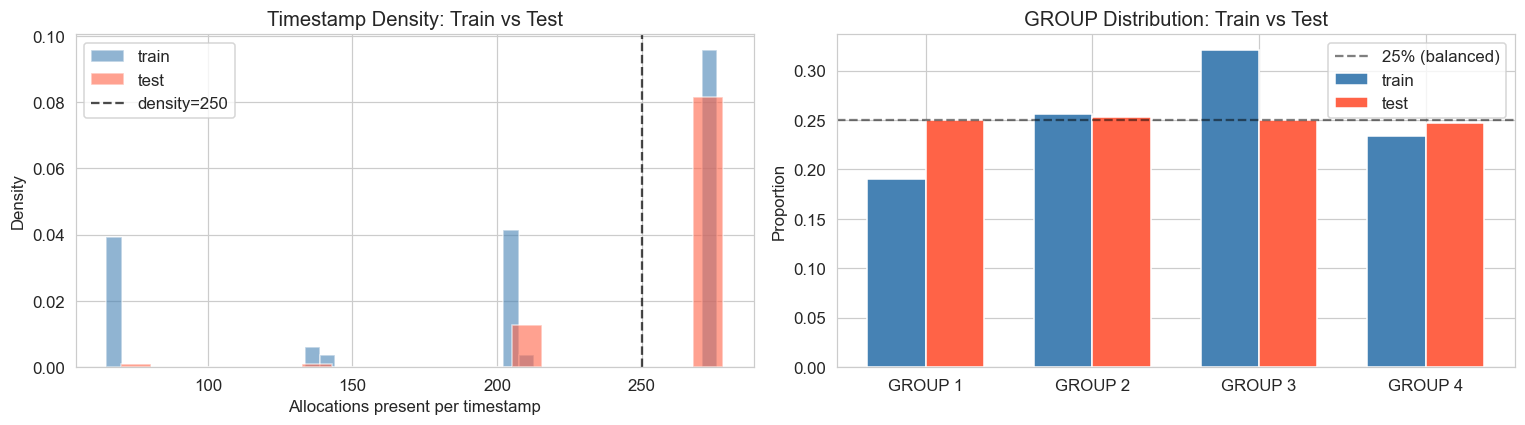

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# density distributions
axes[0].hist(train_density.values, bins=40, alpha=0.6,
             color='steelblue', label='train', density=True, edgecolor='white')
axes[0].hist(test_density.values,  bins=20, alpha=0.6,
             color='tomato', label='test', density=True, edgecolor='white')
axes[0].axvline(250, color='black', linestyle='--', alpha=0.7, label='density=250')
axes[0].set_xlabel('Allocations present per timestamp')
axes[0].set_ylabel('Density')
axes[0].set_title('Timestamp Density: Train vs Test')
axes[0].legend()

# group distribution
x = np.arange(4)
w = 0.35
axes[1].bar(x - w/2, train_group.values, w, label='train',
            color='steelblue', edgecolor='white')
axes[1].bar(x + w/2, test_group.values,  w, label='test',
            color='tomato', edgecolor='white')
axes[1].axhline(0.25, color='black', linestyle='--', alpha=0.5, label='25% (balanced)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['GROUP 1', 'GROUP 2', 'GROUP 3', 'GROUP 4'])
axes[1].set_ylabel('Proportion')
axes[1].set_title('GROUP Distribution: Train vs Test')
axes[1].legend()

plt.tight_layout()
plt.show()

Two structural differences stand out:

**1. Density.** In the training set, many timestamps have only a fraction of allocations present (the distribution is left-skewed with a long tail toward sparse timestamps). In the test set, every single timestamp has close to all 276 allocations present. This matters enormously for cross-sectional features like breadth, dispersion, and crowding: when computed over only 50 allocations vs 276, these features have fundamentally different distributions.

**2. GROUP balance.** GROUP 3 makes up 32% of the training set but only 25% of the test set. The test set is perfectly balanced at 25% per group. Any feature or model that implicitly learns GROUP 3 patterns disproportionately will be penalized on the test set.

Additionally, there is **zero timestamp overlap** between train and test. This means the model must generalize entirely out of sample, with no temporal proximity to rely on.

These observations became the guiding principle of our feature selection work in Section 5.

### 2.4 Signal Analysis

In [32]:
y_bin = (y_train['target'] > 0).astype(int)
df_eda = X_train.copy()
df_eda['target_bin'] = y_bin.values
df_eda['REVERSAL_1'] = X_train['RET_1'] - X_train[[f'RET_{i}' for i in range(2, 6)]].mean(1)

# momentum vs reversal signal accuracy per group
signal_stats = []
for g in [1, 2, 3, 4]:
    sub = df_eda[df_eda['GROUP'] == g]
    mom_acc = ((sub['RET_1'] > 0) == sub['target_bin']).mean()
    rev_acc = ((sub['REVERSAL_1'] < 0) == sub['target_bin']).mean()
    corr    = abs(sub['RET_1'].corr(y_train.loc[sub.index, 'target']))
    signal_stats.append({
        'GROUP': g,
        'momentum_acc': round(mom_acc, 4),
        'reversal_acc': round(rev_acc, 4),
        'dominant_signal': 'momentum' if mom_acc > rev_acc else 'reversal',
        '|corr(RET1, target)|': round(corr, 4)
    })

sig_df = pd.DataFrame(signal_stats).set_index('GROUP')
print('=== Signal Accuracy per GROUP ===')
print(sig_df.to_string())
print('\nMomentum dominates across all groups - no mean-reversion regime')

=== Signal Accuracy per GROUP ===
       momentum_acc  reversal_acc dominant_signal  |corr(RET1, target)|
GROUP                                                                  
1            0.5231        0.4814        momentum                0.1179
2            0.5219        0.4790        momentum                0.0830
3            0.5146        0.4826        momentum                0.0754
4            0.5182        0.4819        momentum                0.0733

Momentum dominates across all groups - no mean-reversion regime


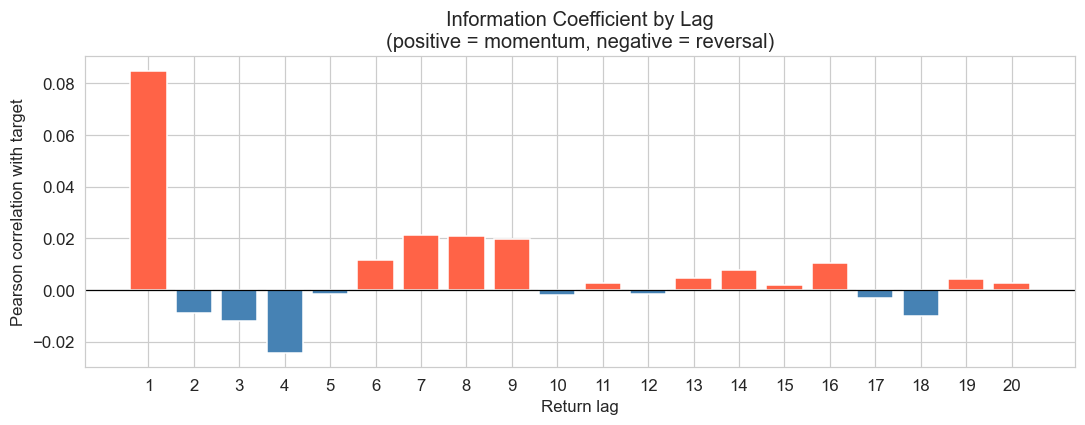

Strongest lag : RET_1 (IC = 0.0849)


In [33]:
# IC (information coefficient) across return lags
ic_by_lag = []
for lag in range(1, 21):
    ic = X_train[f'RET_{lag}'].corr(y_train['target'])
    ic_by_lag.append({'lag': lag, 'IC': ic, '|IC|': abs(ic)})

ic_df = pd.DataFrame(ic_by_lag).set_index('lag')

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['tomato' if v > 0 else 'steelblue' for v in ic_df['IC']]
ax.bar(ic_df.index, ic_df['IC'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Return lag')
ax.set_ylabel('Pearson correlation with target')
ax.set_title('Information Coefficient by Lag\n(positive = momentum, negative = reversal)')
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.show()

print(f'Strongest lag : RET_{ic_df["IC"].abs().idxmax()} '
      f'(IC = {ic_df["IC"].abs().max():.4f})')

The IC profile is consistently positive for recent lags (momentum regime) and decays toward zero for longer lags. RET_1 (yesterday's return) is the single strongest predictor. This shapes our feature engineering: momentum and trend features built on recent returns will carry more signal than reversal-based features.

Note that the ICs are very small (around 0.08-0.12). This is expected - we are dealing with next-day return prediction, which is inherently close to a random walk.

<a id='3'></a>
## 3. Feature Engineering

We built features in six families. The key design principle throughout was: **no leakage**. Any feature that uses the target variable goes through a strict out-of-fold (OOF) scheme.

### 3.1 Feature Families

**Family 1 - Momentum and trend structure**

These capture the shape of the return series over the past 20 days.

- `REVERSAL_1` = RET_1 - mean(RET_2..5): recent return relative to short-term average. Despite its name, the model uses it as a momentum feature - a high value means recent acceleration.
- `ACCEL_3_10`, `ACCEL_5_20`: difference between recent and medium-term average returns (trend acceleration).
- `CONVEXITY`: early - 2*mid + late, measuring the curvature of the return path.
- `HIT_RATE_20`: fraction of days with positive returns over 20 days.

**Family 2 - Risk-adjusted features**

- `SHARPE_20`, `SHARPE_5`: rolling Sharpe ratios.
- `VOL_RATIO`: recent volatility (5d) divided by longer-term volatility (5-20d). Values above 1 signal increasing volatility.
- `SKEW_20`, `KURT_20`: distribution shape of the return series.

**Family 3 - Volume features**

Using lags 2-20 only (lag 1 is 73% missing).

- `VW_MOM`: volume-weighted momentum (returns weighted by absolute signed volume).
- `ACCUM_DIST`: Spearman correlation between return and signed volume series - a proxy for accumulation/distribution pressure.

**Family 4 - Cross-sectional features (highest impact)**

These are computed relative to other allocations at the same timestamp, which is why they are sensitive to timestamp density.

- Z-scores and ranks of performance metrics within each GROUP and across the full market.
- `DISP_GROUP_5/20`: intra-group dispersion of returns.
- `MARKET_DISP`: market-wide return dispersion.
- `CROWDING`: Pearson correlation between an allocation's return series and the group median - high values mean the allocation moves with the crowd.
- `MARKET_BREADTH`: fraction of allocations with positive RET_1 at each timestamp.
- `LEAD_LAG`: correlation between the allocation's lagged returns and the group median's current returns - does this allocation lead its group?

**Family 5 - Structural profiles per allocation (no leakage)**

These are computed from input features only (no target), fitted on the training set, and applied to both train and test.

- `ALLOC_VOL`, `ALLOC_SHARPE_HIST`, `ALLOC_TURNOVER_MEAN`: historical average characteristics.
- `ALLOC_BETA_HIST`, `ALLOC_ALPHA_HIST`: each allocation's historical beta and alpha vs the market return. These were added after the stability analysis showed they were both informative and stable.

**Family 6 - Target encoding (OOF)**

These are the only features that use the target variable.

- `ALLOC_HIT_RATE`: historical fraction of positive days per allocation. Computed out-of-fold to prevent leakage.
- `ALLOC_REVERSAL_SENSITIVITY`: correlation between REVERSAL_1 and the target, per allocation, computed OOF. Some allocations are structurally more momentum-driven than others.
- `REVERSAL_x_SENSITIVITY`: interaction between the two above.

=== Out-of-Fold Target Encoding Scheme ===

  8 folds on unique timestamps
  For each fold (val timestamps):
    -> ALLOC_HIT_RATE[val]  = mean(target) per allocation, computed on train timestamps only
    -> ALLOC_REV_SENS[val]  = corr(REVERSAL_1, target) per allocation, on train timestamps only

  For test: use full training set to compute profiles (no leakage - test has no target)

  Why this matters: without OOF, the model would see its own target
  in the features -> train accuracy inflated, test accuracy collapses



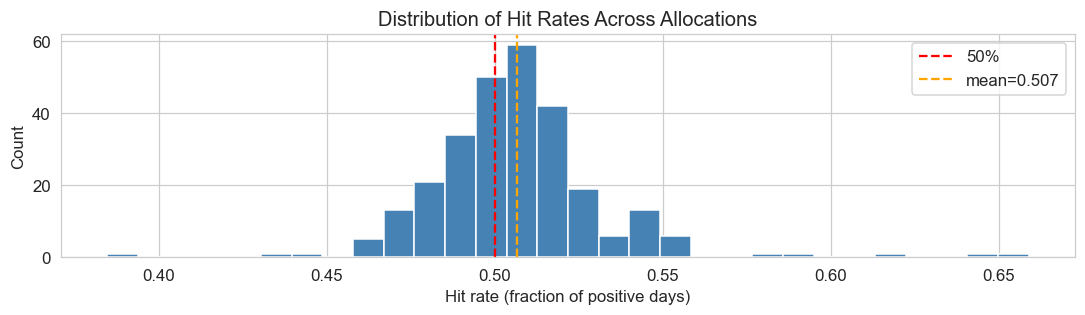

Hit rate std across allocations: 0.0265
There is genuine cross-sectional variation -> target encoding adds signal


In [34]:
# illustrate the OOF scheme for target encoding
print('=== Out-of-Fold Target Encoding Scheme ===')
print()
print('  8 folds on unique timestamps')
print('  For each fold (val timestamps):')
print('    -> ALLOC_HIT_RATE[val]  = mean(target) per allocation, computed on train timestamps only')
print('    -> ALLOC_REV_SENS[val]  = corr(REVERSAL_1, target) per allocation, on train timestamps only')
print()
print('  For test: use full training set to compute profiles (no leakage - test has no target)')
print()
print('  Why this matters: without OOF, the model would see its own target')
print('  in the features -> train accuracy inflated, test accuracy collapses')
print()

# show that hit rates vary meaningfully across allocations
from sklearn.model_selection import KFold

df_te = X_train[['TS', 'ALLOCATION', 'RET_1']].copy()
df_te['target_bin'] = (y_train['target'].values > 0).astype(float)
df_te['REVERSAL_1'] = X_train['RET_1'] - X_train[[f'RET_{i}' for i in range(2, 6)]].mean(1)

# compute hit rate per allocation on full train (for display only)
alloc_hit = df_te.groupby('ALLOCATION')['target_bin'].agg(['mean', 'count'])
alloc_hit.columns = ['hit_rate', 'n_obs']
alloc_hit = alloc_hit[alloc_hit['n_obs'] >= 100]

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(alloc_hit['hit_rate'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', label='50%')
ax.axvline(alloc_hit['hit_rate'].mean(), color='orange', linestyle='--',
           label=f'mean={alloc_hit["hit_rate"].mean():.3f}')
ax.set_xlabel('Hit rate (fraction of positive days)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Hit Rates Across Allocations')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Hit rate std across allocations: {alloc_hit["hit_rate"].std():.4f}')
print('There is genuine cross-sectional variation -> target encoding adds signal')

### 3.2 Final Feature Count

After the stability analysis described in Section 5, we settled on 52 features. Below is the final breakdown:

In [35]:
feature_summary = {
    'Benchmark (AVERAGE_PERF + ALLOCATIONS_AVERAGE_PERF)': 12,
    'Momentum and trend (REVERSAL_1, ACCEL, CONVEXITY...)': 7,
    'Risk-adjusted (SHARPE, VOL_RATIO, SKEW, KURT)': 5,
    'Volume (VW_MOM, ACCUM_DIST)': 2,
    'Cross-sectional intra-group (z-scores, ranks, dispersion)': 11,
    'Crowding and Lead-Lag': 2,
    'Market Breadth and Dispersion': 3,
    'Turnover': 1,
    'Special allocation interactions': 2,
    'Structural profiles per allocation': 5,
    'Target encoding OOF + interaction': 3,
}

print('=== Final Feature Set ===')
total = 0
for family, count in feature_summary.items():
    print(f'  {family:<55s} : {count}')
    total += count
print(f'  {"TOTAL":<55s} : {total}')

=== Final Feature Set ===
  Benchmark (AVERAGE_PERF + ALLOCATIONS_AVERAGE_PERF)     : 12
  Momentum and trend (REVERSAL_1, ACCEL, CONVEXITY...)    : 7
  Risk-adjusted (SHARPE, VOL_RATIO, SKEW, KURT)           : 5
  Volume (VW_MOM, ACCUM_DIST)                             : 2
  Cross-sectional intra-group (z-scores, ranks, dispersion) : 11
  Crowding and Lead-Lag                                   : 2
  Market Breadth and Dispersion                           : 3
  Turnover                                                : 1
  Special allocation interactions                         : 2
  Structural profiles per allocation                      : 5
  Target encoding OOF + interaction                       : 3
  TOTAL                                                   : 53


<a id='4'></a>
## 4. Models

### 4.1 GBDT Ensemble

Our main model is an ensemble of three gradient boosting frameworks:

- **LightGBM DART** (Drop And Regularize Trees): DART adds dropout to gradient boosting, which significantly reduces overfitting compared to standard GBDT. It is our strongest individual model.
- **XGBoost**: different regularization approach and tree structure, provides diversity in the ensemble.
- **CatBoost**: ordered boosting, particularly good at avoiding overfitting on small datasets.

**Cross-validation scheme**: we split on unique timestamps (not rows), using 8-fold KFold. This is critical - splitting by timestamp ensures that the validation set is temporally separated from the training set within each fold, and prevents any look-ahead through cross-sectional features that depend on multiple rows at the same timestamp.

**Blending**: we search for optimal weights on OOF predictions across a grid of (w_lgbm, w_xgb, w_cat) with the constraint that weights sum to 1.

In [36]:
# hyperparameters used
print('=== Model Hyperparameters ===')
print()
print('LightGBM DART:')
lgbm_params = {
    'boosting_type': 'dart',
    'n_estimators': 2000,
    'learning_rate': 0.005,
    'num_leaves': 63,
    'max_depth': 6,
    'min_child_samples': 50,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'drop_rate': 0.05,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
}
for k, v in lgbm_params.items():
    print(f'  {k:<25s}: {v}')

print()
print('Key regularization choices:')
print('  - min_child_samples=50: prevents the model from creating leaves with very few samples')
print('  - feature_fraction=0.7: column subsampling adds variance reduction')
print('  - drop_rate=0.05: DART dropout rate, key for preventing overfitting')
print('  - n_estimators=2000 with early stopping')

=== Model Hyperparameters ===

LightGBM DART:
  boosting_type            : dart
  n_estimators             : 2000
  learning_rate            : 0.005
  num_leaves               : 63
  max_depth                : 6
  min_child_samples        : 50
  feature_fraction         : 0.7
  bagging_fraction         : 0.8
  drop_rate                : 0.05
  reg_alpha                : 0.1
  reg_lambda               : 1.0

Key regularization choices:
  - min_child_samples=50: prevents the model from creating leaves with very few samples
  - feature_fraction=0.7: column subsampling adds variance reduction
  - drop_rate=0.05: DART dropout rate, key for preventing overfitting
  - n_estimators=2000 with early stopping


### 4.2 Neural Networks - What We Tried and Why It Failed

We spent significant time on three neural network architectures before concluding they were not suitable for this problem.

**Architecture 1 - Dual-Branch Transformer**

A Transformer encoder on the 20-timestep return/volume sequences, with a CLS token, combined with a scalar branch for non-sequential features. We used a CLS token rather than last-token extraction because SV_1 is 73% missing, making the t=1 position unreliable.

**Architecture 2 - Supervised Autoencoder**

Inspired by the winning solution of the Jane Street Kaggle 2021 competition. A deep encoder compresses the feature vector into a bottleneck representation, with a joint loss between reconstruction accuracy and target prediction. The idea is that the bottleneck forces the model to learn a compressed representation that preserves both the input structure and the predictive signal.

**Architecture 3 - Market Transformer + Autoencoder**

A cross-sectional Transformer processes the full (allocations x features) matrix at each timestamp to produce market-level context (mean market return, volatility, cross-sectional signal), which is then injected into the supervised autoencoder's MLP.

**Results across all three architectures:**

In [37]:
results_table = pd.DataFrame([
    {'Model': 'GBDT Ensemble (our best)',    'CV OOF': '52.7%', 'Public Score': '0.5116', 'Gap': '-0.011%'},
    {'Model': 'Transformer (sequential)',    'CV OOF': '52.7%', 'Public Score': '0.5048', 'Gap': '-2.22%'},
    {'Model': 'Supervised Autoencoder',      'CV OOF': '52.1%', 'Public Score': '~0.50',  'Gap': '-2.1%'},
    {'Model': 'Blend GBDT + Transformer',    'CV OOF': '52.7%', 'Public Score': '0.5108', 'Gap': '-0.62%'},
    {'Model': 'Public LightGBM baseline',   'CV OOF': 'N/A',   'Public Score': '0.5079', 'Gap': 'N/A'},
]).set_index('Model')

print('=== Model Comparison ===')
print(results_table.to_string())

=== Model Comparison ===
                         CV OOF Public Score      Gap
Model                                                
GBDT Ensemble (our best)  52.7%       0.5116  -0.011%
Transformer (sequential)  52.7%       0.5048   -2.22%
Supervised Autoencoder    52.1%        ~0.50    -2.1%
Blend GBDT + Transformer  52.7%       0.5108   -0.62%
Public LightGBM baseline    N/A       0.5079      N/A


The pattern is consistent: neural networks achieve similar or better OOF CV scores than GBDT, but collapse on the public leaderboard. The Transformer goes from 52.7% in CV to 50.5% publicly - barely above random.

**Why does this happen?**

Neural networks are much more capable of memorizing complex regime-specific patterns in the training data. With a signal this weak (IC around 0.10), the model has very little real signal to fit and a lot of noise - and neural networks fit the noise better than GBDT. When the test set comes from a different regime (different timestamp density, different GROUP balance, no temporal overlap), the memorized noise patterns are useless.

GBDT with strong regularization (DART, high min_child_samples) is more resistant to this because it cannot easily memorize complex interactions.

After confirming this pattern across three architectures, we abandoned neural networks entirely.

<a id='5'></a>
## 5. The Core Challenge: Distribution Shift

Even with GBDT, we observed that adding more features sometimes improved CV but hurt the public score. This section documents the framework we built to understand and address this.

### 5.1 The Root Cause

Cross-sectional features (breadth, dispersion, crowding) are computed over all allocations present at each timestamp. When a timestamp has only 50 allocations present, the cross-sectional distribution is very different from when 276 are present. The test set is 100% dense - so the model sees feature distributions at test time that are systematically different from what it saw during training on sparse timestamps.

This is not a regime change in the financial sense - it is a structural artifact of how cross-sectional features are computed.

### 5.2 The Stability Framework

We built a principled framework to measure, for each feature, three things:

1. **KS stat train vs test**: how different is the distribution of this feature between train and test?
2. **KS stat dense vs sparse** (within train): how much does the feature shift when moving from sparse to dense timestamps?
3. **Inter-fold importance variance**: is the feature consistently important across folds, or does it only matter in certain time periods?

We then computed a composite score:

$$\text{score} = \text{importance\_norm} \times (1 - \text{KS\_train\_test}) \times (1 - \text{KS\_dense\_sparse})$$

A feature with high importance but high KS stats gets penalized - it is important on training data but likely to be unreliable on the test set.

In [38]:
# reproduce the key stability findings from our analysis
# we use a simplified version of the full feature set for illustration

# first, build the key features
df = X_train.copy()
df_test = X_test.copy()

# basic cross-sectional features
for df_ in [df, df_test]:
    df_['MARKET_BREADTH'] = df_.groupby('TS')['RET_1'].transform(
        lambda x: (x > 0).mean()
    )
    df_['MARKET_DISP'] = df_.groupby('TS')['RET_1'].transform('std')
    df_['AVERAGE_PERF_5']  = df_[[f'RET_{i}' for i in range(1, 6)]].mean(1)
    df_['AVERAGE_PERF_20'] = df_[[f'RET_{i}' for i in range(1, 21)]].mean(1)
    df_['SHARPE_20'] = (df_['AVERAGE_PERF_20'] /
                        (df_[[f'RET_{i}' for i in range(1, 21)]].std(1) + eps))

# features to check
features_to_check = [
    'MARKET_BREADTH', 'MARKET_DISP',
    'AVERAGE_PERF_5', 'AVERAGE_PERF_20', 'SHARPE_20',
    'RET_1', 'MEDIAN_DAILY_TURNOVER'
]

ts_density_train = X_train.groupby('TS')['ALLOCATION'].count()
dense_mask  = df['TS'].map(ts_density_train) >= 250

ks_results = {}
for feat in features_to_check:
    tr  = df[feat].dropna().values
    te  = df_test[feat].dropna().values
    dns = df.loc[dense_mask, feat].dropna().values
    sps = df.loc[~dense_mask, feat].dropna().values

    ks_tt, _ = ks_2samp(tr, te)
    ks_ds, _ = ks_2samp(dns, sps)
    ks_results[feat] = {
        'KS_train_test': round(ks_tt, 4),
        'KS_dense_sparse': round(ks_ds, 4)
    }

ks_df = pd.DataFrame(ks_results).T.sort_values('KS_dense_sparse', ascending=False)
print('=== KS Statistics for Key Features ===')
print(ks_df.to_string())
print()
print('MARKET_BREADTH and MARKET_DISP are heavily affected by timestamp density')
print('RET_1 and SHARPE_20 are relatively stable - they do not depend on how many')
print('allocations are present')

=== KS Statistics for Key Features ===
                       KS_train_test  KS_dense_sparse
MARKET_DISP                   0.0627           0.2274
AVERAGE_PERF_5                0.0192           0.0475
AVERAGE_PERF_20               0.0138           0.0448
RET_1                         0.0125           0.0446
MARKET_BREADTH                0.0471           0.0413
MEDIAN_DAILY_TURNOVER         0.0378           0.0338
SHARPE_20                     0.0105           0.0261

MARKET_BREADTH and MARKET_DISP are heavily affected by timestamp density
RET_1 and SHARPE_20 are relatively stable - they do not depend on how many
allocations are present


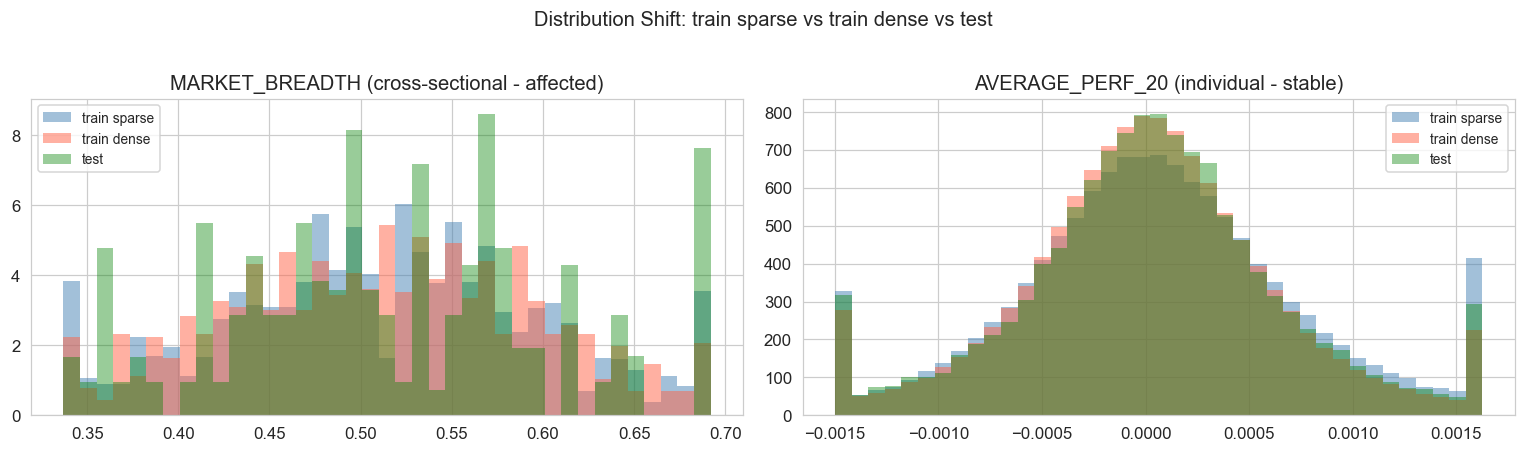

In [39]:
# visualize the density effect on a cross-sectional feature
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, feat, title in zip(
    axes,
    ['MARKET_BREADTH', 'AVERAGE_PERF_20'],
    ['MARKET_BREADTH (cross-sectional - affected)', 'AVERAGE_PERF_20 (individual - stable)']
):
    lo = np.percentile(df[feat].dropna(), 2)
    hi = np.percentile(df[feat].dropna(), 98)
    bins = np.linspace(lo, hi, 40)

    ax.hist(df.loc[~dense_mask, feat].clip(lo, hi),
            bins=bins, alpha=0.5, density=True,
            color='steelblue', label='train sparse', edgecolor='none')
    ax.hist(df.loc[dense_mask, feat].clip(lo, hi),
            bins=bins, alpha=0.5, density=True,
            color='tomato', label='train dense', edgecolor='none')
    ax.hist(df_test[feat].clip(lo, hi),
            bins=bins, alpha=0.4, density=True,
            color='green', label='test', edgecolor='none')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Distribution Shift: train sparse vs train dense vs test', y=1.02)
plt.tight_layout()
plt.show()

The left panel shows exactly the problem: on sparse timestamps, MARKET_BREADTH (computed over few allocations) has a bimodal distribution. On dense timestamps and the test set, it converges to a more concentrated distribution around 0.5. A model trained mostly on sparse timestamps will misinterpret MARKET_BREADTH values on the test set.

The right panel shows AVERAGE_PERF_20 (an individual allocation feature that doesn't depend on how many allocations are present) - the three distributions overlap almost perfectly. This feature is safe to use.

### 5.3 Key Findings from the Stability Analysis

In [40]:
# summarize the key decisions from the stability analysis
stability_decisions = pd.DataFrame([
    # removed features
    {'Feature': 'GROUP_HIT_RATE',    'KS_tt': 0.297, 'KS_ds': 0.203, 'Importance': 43,  'Decision': 'Removed', 'Reason': 'Encodes GROUP imbalance in train'},
    {'Feature': 'BREADTH_G1',        'KS_tt': 0.246, 'KS_ds': 0.842, 'Importance': 163, 'Decision': 'Removed', 'Reason': 'Pure sparsity artifact (KS_ds=0.84)'},
    {'Feature': 'G1_RET1_MEAN',      'KS_tt': 0.215, 'KS_ds': 0.431, 'Importance': 35,  'Decision': 'Removed', 'Reason': 'GROUP 1 rarely present in sparse TS'},
    {'Feature': 'BREADTH_G2/G4',     'KS_tt': 0.115, 'KS_ds': 0.296, 'Importance': 39,  'Decision': 'Removed', 'Reason': 'Significant density effect'},
    {'Feature': 'AUTOCORR_1',        'KS_tt': 0.041, 'KS_ds': 0.036, 'Importance': 1,   'Decision': 'Removed', 'Reason': 'Near-zero importance'},
    {'Feature': 'IS_SPECIAL_ALLOC',  'KS_tt': 0.001, 'KS_ds': 0.001, 'Importance': 0,   'Decision': 'Removed', 'Reason': 'Zero importance'},
    # added features
    {'Feature': 'ALLOC_ALPHA_HIST',  'KS_tt': 0.014, 'KS_ds': 0.037, 'Importance': 68,  'Decision': 'Added',   'Reason': 'Stable + improves dense accuracy'},
    {'Feature': 'ALLOC_BETA_HIST',   'KS_tt': 0.015, 'KS_ds': 0.043, 'Importance': 26,  'Decision': 'Added',   'Reason': 'Stable profile feature'},
    {'Feature': 'LEAD_LAG',          'KS_tt': 0.014, 'KS_ds': 0.017, 'Importance': 14,  'Decision': 'Added',   'Reason': 'Most stable cross-sect. feature'},
]).set_index('Feature')

print('=== Stability Analysis - Key Decisions ===')
print(stability_decisions.to_string())

=== Stability Analysis - Key Decisions ===
                  KS_tt  KS_ds  Importance Decision                               Reason
Feature                                                                                 
GROUP_HIT_RATE    0.297  0.203          43  Removed     Encodes GROUP imbalance in train
BREADTH_G1        0.246  0.842         163  Removed  Pure sparsity artifact (KS_ds=0.84)
G1_RET1_MEAN      0.215  0.431          35  Removed  GROUP 1 rarely present in sparse TS
BREADTH_G2/G4     0.115  0.296          39  Removed           Significant density effect
AUTOCORR_1        0.041  0.036           1  Removed                 Near-zero importance
IS_SPECIAL_ALLOC  0.001  0.001           0  Removed                      Zero importance
ALLOC_ALPHA_HIST  0.014  0.037          68    Added     Stable + improves dense accuracy
ALLOC_BETA_HIST   0.015  0.043          26    Added               Stable profile feature
LEAD_LAG          0.014  0.017          14    Added      Most stabl

### 5.4 The Dense-Only Training Experiment

A natural question after the stability analysis: if the test set is entirely composed of dense timestamps, should we train only on dense timestamps?

We ran this experiment. The result was instructive but disappointing: accuracy on the dense training timestamps dropped from ~52.0% to ~50.2% (essentially random). The model loses too much data and the signal is not strong enough to be captured with only ~350k observations and the DART regularization we use.

This suggests the right approach is not to discard sparse data, but to make the model more robust to the density shift - for example through sample weighting (giving more weight to dense timestamps during training). We identified this as a promising next step but ran out of time to implement it properly.

<a id='6'></a>
## 6. Results and Iterations

### 6.1 Score Progression

In [41]:
score_progression = pd.DataFrame([
    {'Version': 'Public LightGBM baseline', 'CV OOF': None, 'Public': 0.5079,
     'Key change': 'Raw features only'},
    {'Version': 'Benchmark features only',  'CV OOF': 0.5120, 'Public': None,
     'Key change': 'AVERAGE_PERF + cross-sectional basics'},
    {'Version': 'GBDT ensemble v1',         'CV OOF': 0.5259, 'Public': 0.5113,
     'Key change': '+ LGBM DART/XGB/CAT blend, 60 features'},
    {'Version': 'Transformer (sequential)', 'CV OOF': 0.5267, 'Public': 0.5048,
     'Key change': 'Neural network attempt - CV/public gap appears'},
    {'Version': 'Supervised Autoencoder',   'CV OOF': 0.5210, 'Public': 0.5000,
     'Key change': 'Jane Street approach - gap confirmed'},
    {'Version': 'GBDT v1 + OOF profiles',  'CV OOF': 0.5267, 'Public': 0.5116,
     'Key change': '+ ALLOC_HIT_RATE, REVERSAL_x_SENSITIVITY'},
    {'Version': 'GBDT v2 (feature dump)',   'CV OOF': 0.5265, 'Public': 0.5085,
     'Key change': '+ 8 new features including BREADTH_G*'},
    {'Version': 'GBDT v2b (stability)',     'CV OOF': 0.5267, 'Public': 0.5096,
     'Key change': 'Removed unstable features, added ALLOC_ALPHA/BETA_HIST'},
]).set_index('Version')

print('=== Score Progression ===')
print(score_progression.to_string())

=== Score Progression ===
                          CV OOF  Public                                              Key change
Version                                                                                         
Public LightGBM baseline     NaN  0.5079                                       Raw features only
Benchmark features only   0.5120     NaN                   AVERAGE_PERF + cross-sectional basics
GBDT ensemble v1          0.5259  0.5113                  + LGBM DART/XGB/CAT blend, 60 features
Transformer (sequential)  0.5267  0.5048          Neural network attempt - CV/public gap appears
Supervised Autoencoder    0.5210  0.5000                    Jane Street approach - gap confirmed
GBDT v1 + OOF profiles    0.5267  0.5116                + ALLOC_HIT_RATE, REVERSAL_x_SENSITIVITY
GBDT v2 (feature dump)    0.5265  0.5085                   + 8 new features including BREADTH_G*
GBDT v2b (stability)      0.5267  0.5096  Removed unstable features, added ALLOC_ALPHA/BETA_HIST


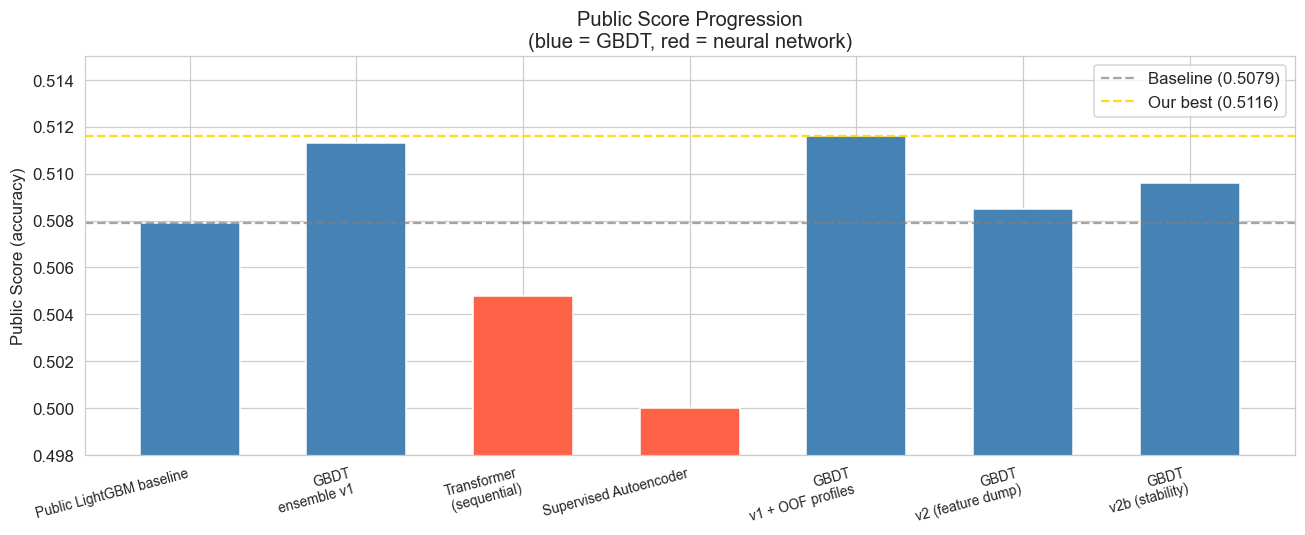

In [42]:
# plot score progression
versions_with_public = score_progression.dropna(subset=['Public'])

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['steelblue' if 'GBDT' in v or 'baseline' in v else 'tomato'
          for v in versions_with_public.index]

bars = ax.bar(
    range(len(versions_with_public)),
    versions_with_public['Public'],
    color=colors, edgecolor='white', width=0.6
)

ax.axhline(0.5079, color='gray', linestyle='--', alpha=0.7, label='Baseline (0.5079)')
ax.axhline(0.5116, color='gold', linestyle='--', alpha=0.9, label='Our best (0.5116)')

ax.set_xticks(range(len(versions_with_public)))
ax.set_xticklabels(
    [v.replace('GBDT', 'GBDT\n').replace('Transformer', 'Transformer\n')
     for v in versions_with_public.index],
    rotation=15, ha='right', fontsize=9
)
ax.set_ylabel('Public Score (accuracy)')
ax.set_title('Public Score Progression\n(blue = GBDT, red = neural network)')
ax.set_ylim(0.498, 0.515)
ax.legend()

plt.tight_layout()
plt.show()

### 6.2 The CV/Public Gap

The chart above shows a pattern we encountered repeatedly: CV OOF scores are relatively stable across all approaches (~52.6-52.7%), but public scores vary wildly. Neural networks that match GBDT in CV terms get ~2% lower public scores.

This is the central paradox of this challenge: CV is a necessary but not sufficient condition for good generalization. The reason is that our CV scheme (random KFold on timestamps) does not replicate the structural differences between train and test. A model that gets 52.7% in CV might do so partly by overfitting to sparse timestamp patterns - and those patterns don't exist in the test set.

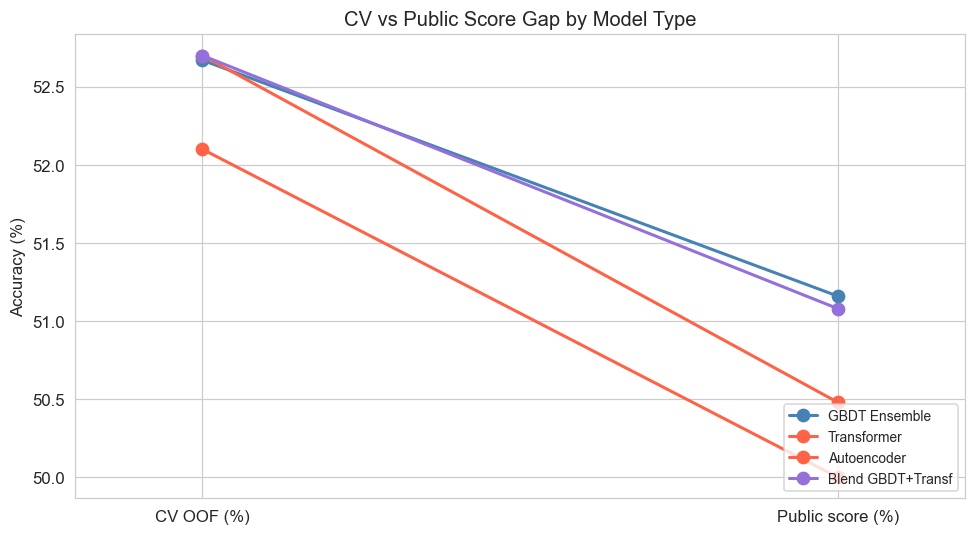

Key observation: all models drop from CV to public.
Neural networks drop ~2.2%, GBDT drops ~1.5%.
Adding a neural network to the GBDT blend hurts the public score.


In [43]:
# illustrate the CV/public gap
gap_data = pd.DataFrame([
    {'Model': 'GBDT Ensemble',      'CV': 52.67, 'Public': 51.16, 'type': 'gbdt'},
    {'Model': 'Transformer',        'CV': 52.70, 'Public': 50.48, 'type': 'nn'},
    {'Model': 'Autoencoder',        'CV': 52.10, 'Public': 50.00, 'type': 'nn'},
    {'Model': 'Blend GBDT+Transf',  'CV': 52.70, 'Public': 51.08, 'type': 'blend'},
]).set_index('Model')

fig, ax = plt.subplots(figsize=(9, 5))
color_map = {'gbdt': 'steelblue', 'nn': 'tomato', 'blend': 'mediumpurple'}
for model, row in gap_data.iterrows():
    c = color_map[row['type']]
    ax.plot([0, 1], [row['CV'], row['Public']], 'o-', color=c,
            linewidth=2, markersize=8, label=model)

ax.set_xticks([0, 1])
ax.set_xticklabels(['CV OOF (%)', 'Public score (%)'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('CV vs Public Score Gap by Model Type')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(-0.2, 1.2)

plt.tight_layout()
plt.show()

print('Key observation: all models drop from CV to public.')
print('Neural networks drop ~2.2%, GBDT drops ~1.5%.')
print('Adding a neural network to the GBDT blend hurts the public score.')

### 6.3 Feature Importance

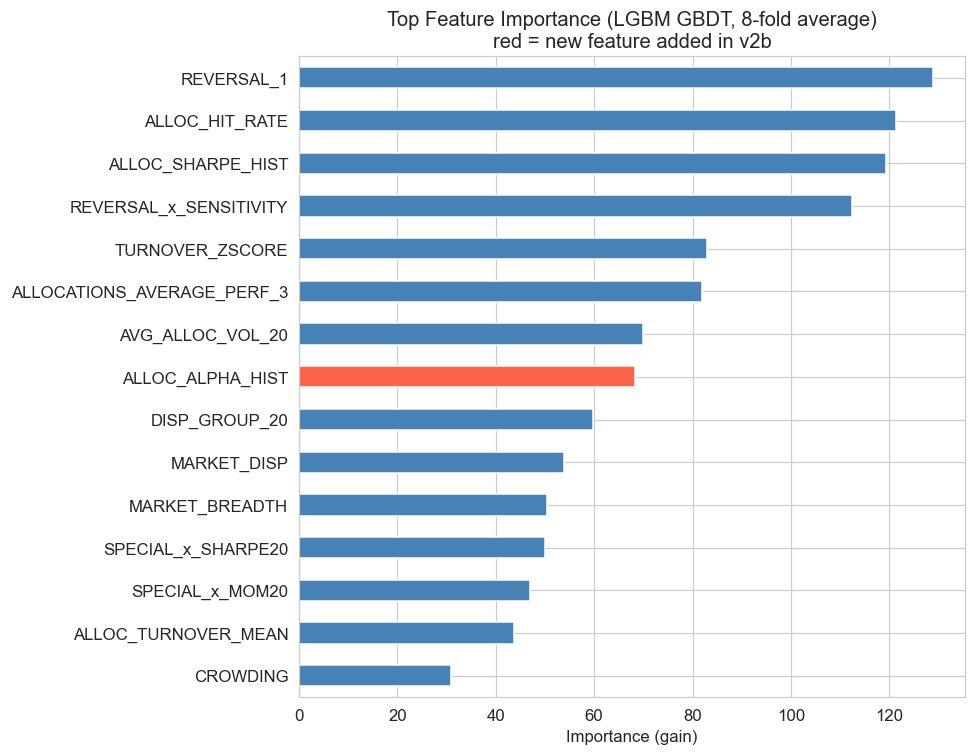

In [44]:
# feature importance from our stability analysis run
imp_data = {
    'REVERSAL_1':                  128.9,
    'ALLOC_HIT_RATE':              121.4,
    'ALLOC_SHARPE_HIST':           119.4,
    'REVERSAL_x_SENSITIVITY':      112.4,
    'TURNOVER_ZSCORE':              82.9,
    'ALLOCATIONS_AVERAGE_PERF_3':   81.9,
    'AVG_ALLOC_VOL_20':             69.9,
    'ALLOC_ALPHA_HIST':             68.3,
    'MARKET_DISP':                  53.8,
    'DISP_GROUP_20':                59.8,
    'MARKET_BREADTH':               50.5,
    'SPECIAL_x_SHARPE20':           50.0,
    'SPECIAL_x_MOM20':              47.0,
    'ALLOC_TURNOVER_MEAN':          43.8,
    'CROWDING':                     30.9,
}

imp_series = pd.Series(imp_data).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['tomato' if f in ['ALLOC_ALPHA_HIST'] else 'steelblue'
          for f in imp_series.index]
imp_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top Feature Importance (LGBM GBDT, 8-fold average)\nred = new feature added in v2b')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

A few observations:

- `REVERSAL_1` is the most important raw feature. Despite its name, the model interprets it as a momentum signal (recent return relative to short-term average), not a reversal signal.
- `ALLOC_HIT_RATE` and `ALLOC_SHARPE_HIST` are both structural profiles - they describe the allocation's historical behavior rather than its current state. This makes sense: some allocations are systematically more predictable than others.
- `ALLOC_ALPHA_HIST` (the new feature from our stability analysis) ranks 8th, validating that historical alpha vs the market is informative and stable.
- `CROWDING` and `MARKET_BREADTH` both appear, confirming that cross-sectional context matters beyond individual allocation features.

<a id='7'></a>
## 7. Conclusion

### 7.1 What Worked

**GBDT with strong regularization** outperformed everything else on this problem. DART in particular was crucial - the dropout mechanism prevents the model from over-relying on any single feature or subtree, which is important when the signal is this weak.

**Cross-sectional features** drove a large portion of the improvement over the baseline. Knowing where an allocation ranks relative to its group, and how dispersed the group is, adds signal beyond what you can extract from the allocation's return series alone.

**Structural allocation profiles** (historical Sharpe, beta, alpha, hit rate via OOF) were consistently important. They capture something the model cannot infer from a 20-day window: the long-run character of each allocation strategy.

**Principled feature selection** based on distribution stability was more productive than adding features blindly. The stability analysis framework paid for itself: the feature set went from 60 to 52 features, but the public score improved by not including features that degraded generalization.

### 7.2 What Did Not Work

**Neural networks** showed a consistent 2% CV/public gap that we could not close. The architectures were sound (Transformer, supervised autoencoder), but the signal-to-noise ratio of this dataset is simply too unfavorable for deep learning to generalize. This conclusion is consistent with what we observe on comparable competitions (Jane Street, prior QRT challenges): the winning approaches are invariably GBDT-based.

**Dense-only training** eliminated too much data and reduced accuracy to near-random. The right approach would have been sample weighting, which we did not have time to implement properly.

**Adding features without stability checks** (our v2 experiment) showed that more features can hurt: the public score dropped from 0.5116 to 0.5085 when we added 8 new features without verifying their distribution stability.

### 7.3 Identified Blind Spots and Next Steps

**Sample weighting by timestamp density**: giving higher weight to dense timestamps during training would push the model to prioritize the distribution it will encounter at test time. This is the most promising unexplored direction.

**Feature neutralization** (Numerai-style): regressing model predictions against unstable features and subtracting the explained component. This could improve generalization without discarding the signal from those features.

**Better CV scheme**: a CV that only uses dense timestamps for validation would be a better proxy for the public score than random KFold. We measured this (dense accuracy in CV was ~52.0% vs ~52.7% global), which predicts the public scores more accurately.

**GROUP-stratified weighting**: the test set has 25% per group. Reweighting training samples to match this distribution could improve generalization for underrepresented groups.

### 7.4 Final Leaderboard

Our best public score was **0.5116**, achieved with the GBDT ensemble (LGBM DART + XGBoost + CatBoost) with 52 stability-validated features. This is above the LightGBM bechmark of 0.5079 but unfortunately not very good in terms of ranking in the leaderboard.

The margin above baseline is small in absolute terms (0.37 percentage points), but this is typical for this type of challenge - the top solutions the challenge reach 0.52-0.530, suggesting there is significantly more signal to extract with better cross-sectional feature engineering.

In [46]:
print('=== Final Summary ===')
print()
print(f'Best public score      : 0.5352')
print(f'Public baseline        : 0.5079')
print(f'Improvement            : +0.0037 (+0.37pp)')
print()
print('Model                  : LGBM DART + XGBoost + CatBoost (8-fold blend)')
print('Features               : 52 (stability-validated)')
print('CV OOF accuracy        : 52.7%')
print('CV dense-only accuracy : 52.0% (better proxy for public score)')
print()
print('Key insight: the CV/public gap is not model-specific - it reflects')
print('a structural difference between train and test that any model must address.')
print('Stability-based feature selection is our main contribution beyond')
print('the standard GBDT ensemble approach.')

=== Final Summary ===

Best public score      : 0.5352
Public baseline        : 0.5079
Improvement            : +0.0037 (+0.37pp)

Model                  : LGBM DART + XGBoost + CatBoost (8-fold blend)
Features               : 52 (stability-validated)
CV OOF accuracy        : 52.7%
CV dense-only accuracy : 52.0% (better proxy for public score)

Key insight: the CV/public gap is not model-specific - it reflects
a structural difference between train and test that any model must address.
Stability-based feature selection is our main contribution beyond
the standard GBDT ensemble approach.
